In [1]:
from pathlib import Path

# CSV가 다른 곳에 있으면 이 셀의 DATA_PATH만 수정하세요.
DATA_PATH = Path("kcb_202306_202405_undersampled_1to4.csv")
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"CSV를 찾을 수 없습니다. 첫 셀의 DATA_PATH를 수정하세요: {DATA_PATH.resolve()}")
print(f"Data: {DATA_PATH.resolve()} ({DATA_PATH.stat().st_size / 2**20:,.1f} MiB)")

Data: C:\Users\cjw03\OneDrive\문서\higher_analysis\kcb_202306_202405_undersampled_1to4.csv (302.1 MiB)


# KCB 전 변수 탐색 분석 (EDA)

**질문.** `LNMON`·`TARGET`을 제외한 모든 변수의 구조, target 관계, 시간 변화, 결측·플래그 관계는 무엇인가?

- 한 행의 단위, `TARGET=1`의 사건과 관찰 기간은 CSV만으로 확정할 수 없다. 코드와 접미사의 업무 의미도 추정하지 않는다.
- 전체 12개월은 기술적 현황이다. 구간 경계는 **앞 6개월(2023-06~2023-11)**에서만 만들고 **뒤 6개월(2023-12~2024-05)**에 그대로 적용한다. 뒤 기간을 변수 선정에 사용하지 않는다.
- 파일명의 언더샘플링 가능성 때문에 관찰된 target 비율을 모집단 발생률로 읽지 않는다.
- 모든 558개 변수는 감사 표와 상세 집계에 포함한다. 상수·희소·고결측·플래그도 남긴다. 분석 가능 여부와 해석 주의 사유를 기록한다.
- **모델 학습, 변수 선택, 최종 변수 수 결정, 성능 평가, 임계값 탐색은 수행하지 않는다.** 그래프의 영문 표기는 한글 글꼴이 없는 환경을 위한 것이다.

## 1. 준비와 메모리 관리

**질문.** 약 16만 × 560 규모를 원본을 변경하지 않고 어떻게 읽을 것인가?

**방법.** CSV를 청크로 읽고 정수·실수 자료형을 안전한 범위에서 축소한다. 큰 정수나 특수값의 정확한 비교를 위해 정수성이 있는 결측 열은 nullable 정수로 보관한다. 출력 표는 상위 몇 행만 표시한다.

In [2]:
import re
import warnings
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2,
                     "font.family": "DejaVu Sans", "axes.unicode_minus": False})

def compact_chunk(frame):
    for name in frame.select_dtypes(include="number").columns:
        s = frame[name]
        if pd.api.types.is_integer_dtype(s):
            frame[name] = pd.to_numeric(s, downcast="integer")
            continue
        values = s.dropna().to_numpy(dtype="float64", copy=False)
        if not len(values):
            frame[name] = s.astype("float32")
            continue
        lo, hi = values.min(), values.max()
        if np.isfinite([lo, hi]).all() and lo >= -2**31 and hi <= 2**31-1 and np.all(values == np.trunc(values)):
            frame[name] = s.astype("Int32")
        elif np.isfinite([lo, hi]).all() and max(abs(lo), abs(hi)) <= 2**24:
            frame[name] = s.astype("float32")
    return frame

parts = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", pd.errors.DtypeWarning)
    for part in pd.read_csv(DATA_PATH, chunksize=12_000, low_memory=False):
        parts.append(compact_chunk(part))
df = pd.concat(parts, ignore_index=True)
del parts, part
for name in df.select_dtypes(include=["str", "object"]).columns:
    if df[name].nunique(dropna=False) <= 100:
        df[name] = df[name].astype("category")
assert {"LNMON", "TARGET"}.issubset(df.columns)
assert df["TARGET"].dropna().isin([0, 1]).all(), "TARGET이 이진값이 아닙니다."
df["LNMON"] = df["LNMON"].astype("int32")
df["TARGET"] = df["TARGET"].astype("int8")
feature_cols = [c for c in df if c not in ("LNMON", "TARGET")]
TRAIN_MONTHS = list(range(202306, 202312))
CHECK_MONTHS = [202312, 202401, 202402, 202403, 202404, 202405]
all_months = sorted(df["LNMON"].unique().tolist())
train_mask = df["LNMON"].isin(TRAIN_MONTHS)
check_mask = df["LNMON"].isin(CHECK_MONTHS)
print(f"Loaded {len(df):,} rows × {df.shape[1]:,} columns; frame memory {df.memory_usage(deep=True).sum()/2**20:,.1f} MiB")
print(f"Discovery: {train_mask.sum():,} rows; stability check: {check_mask.sum():,} rows")

Loaded 162,355 rows × 560 columns; frame memory 192.1 MiB
Discovery: 80,903 rows; stability check: 81,452 rows


## 2. 구조 점검

**질문.** 기간·자료형·문자형 코드·중복·낮은 변동성·접두어 구성은 어떠한가?

**표.** 전체 열이나 원본 행은 펼치지 않고 요약한다. `거의 일정함`은 가장 흔한 값(결측 포함)의 비중이 99.5% 이상인 열로 정의한다. 중복 행은 행 해시로 후보를 찾고 후보만 실제 값으로 확인한다.

In [3]:
shape_table = pd.DataFrame({
    "item": ["rows", "columns", "feature columns", "first month", "last month", "months", "memory MiB"],
    "value": [len(df), df.shape[1], len(feature_cols), min(all_months), max(all_months),
              len(all_months), round(df.memory_usage(deep=True).sum()/2**20, 1)]})
display(shape_table)
display(df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="columns"))
text_cols = [c for c in feature_cols if isinstance(df[c].dtype, pd.CategoricalDtype) or pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c])]
text_values = pd.DataFrame([{"variable": c, "distinct": df[c].nunique(dropna=False),
                             "top values (count)": ", ".join(f"{str(k)} ({v:,})" for k, v in df[c].value_counts(dropna=False).head(6).items())}
                            for c in text_cols])
display(text_values)
display(df["TARGET"].value_counts(dropna=False).sort_index().rename_axis("TARGET").reset_index(name="n").assign(
    share=lambda x: (100*x["n"]/len(df)).round(2)))

row_hash = pd.util.hash_pandas_object(df, index=False)
repeat_hash = row_hash.duplicated(keep=False)
duplicate_rows = int(df.loc[repeat_hash].duplicated().sum()) if repeat_hash.any() else 0
del row_hash, repeat_hash
distinct = {}
dominant_share = {}
for c in feature_cols:
    vc = df[c].value_counts(dropna=False)
    distinct[c] = len(vc)
    dominant_share[c] = vc.iloc[0] / len(df)
distinct = pd.Series(distinct)
dominant_share = pd.Series(dominant_share)
constants = distinct[distinct == 1].index.tolist()
near_constant = dominant_share[(dominant_share >= .995) & (distinct > 1)].sort_values(ascending=False)
display(pd.DataFrame({"check": ["exact duplicate rows", "constant features", "near-constant features (>=99.5%)"],
                      "n": [duplicate_rows, len(constants), len(near_constant)]}))
display(pd.DataFrame({"variable": near_constant.head(12).index,
                      "dominant share %": (100*near_constant.head(12).values).round(2),
                      "distinct incl. missing": distinct.loc[near_constant.head(12).index].values}))

def prefix(c):
    if "_SV_FLAG_" in c: return "SV_FLAG"
    if c.startswith("TS_"): return "TS_"
    match = re.match(r"^[A-Za-z]+", c)
    return match.group(0) if match else "other"
display(pd.Series([prefix(c) for c in feature_cols]).value_counts().rename_axis("prefix").reset_index(name="columns"))
display(Markdown(f"**관찰·해석.** 기간은 {min(all_months)}~{max(all_months)} ({len(all_months)}개월)이고, "
                 f"중복 행은 {duplicate_rows:,}개, 상수 열은 {len(constants)}개, 거의 일정한 열은 {len(near_constant)}개다. "
                 "코드 접두어만으로 변수의 업무 의미나 행 단위는 결정할 수 없다."))

,item,value
0,rows,162355.0
1,columns,560.0
2,feature columns,558.0
3,first month,202306.0
4,last month,202405.0
5,months,12.0
6,memory MiB,192.1


,dtype,columns
0,int8,277
1,int16,105
2,float32,85
3,Int32,54
4,int32,35
5,category,4


,variable,distinct,top values (count)
0,SS1200000,3,"N (126,192), Y (27,842), P (8,321)"
1,AS1C10148,2,"N (109,450), Y (52,905)"
2,TS_VOLATILITY_APS001_FLIPS,3,"Steady (152,403), Changed_1_Time (9,165), Chan..."
3,TS_MOMENTUM_APS001_STATE,4,"Stable_N (108,190), Stable_Y (52,646), Lost_Y ..."


,TARGET,n,share
0,0,129884,80.0
1,1,32471,20.0


,check,n
0,exact duplicate rows,0
1,constant features,10
2,near-constant features (>=99.5%),92


,variable,dominant share %,distinct incl. missing
0,DDC001001,100.0,2
1,DD0140X16,100.0,2
2,DD0210X16,100.0,2
3,DD0210X13,100.0,2
4,DDC006003,100.0,2
5,C1P000005_SV_FLAG_9999999_9,100.0,2
6,DDC005002,100.0,2
7,DD0211X10,100.0,2
8,D30210000,100.0,2
9,D3011000R,100.0,2


,prefix,columns
0,C,124
1,L,95
2,SV_FLAG,88
3,TS_,77
4,DA,33
5,D,31
6,AS,30
7,DUN,16
8,U,14
9,AL,14


**관찰·해석.** 기간은 202306~202405 (12개월)이고, 중복 행은 0개, 상수 열은 10개, 거의 일정한 열은 92개다. 코드 접두어만으로 변수의 업무 의미나 행 단위는 결정할 수 없다.

## 3. 월별 변화

**질문.** 월별 표본 수와 `TARGET=1` 비율이 어떻게 달라지는가? 연속 2개월을 묶어도 같은 흐름인가?

**표·그래프.** 비율의 단위는 %, 표본 수와 양성 건수의 단위는 행이다. 경계선 왼쪽은 탐색 기간, 오른쪽은 안정성 확인 기간이다.

,rows,TARGET=1 rows,TARGET=1 (%)
LNMON,,,
202306,14252,2837,19.91
202307,13669,2781,20.35
202308,13757,2553,18.56
202309,13137,2454,18.68
202310,14057,2705,19.24
202311,12031,2130,17.70
202312,13513,2553,18.89
202401,13707,2716,19.81
202402,12460,2569,20.62


,rows,TARGET=1 rows,TARGET=1 (%)
LNMON,,,
202306–202307,27921,5618,20.12
202308–202309,26894,5007,18.62
202310–202311,26088,4835,18.53
202312–202401,27220,5269,19.36
202402–202403,25553,5272,20.63
202404–202405,28679,6470,22.56


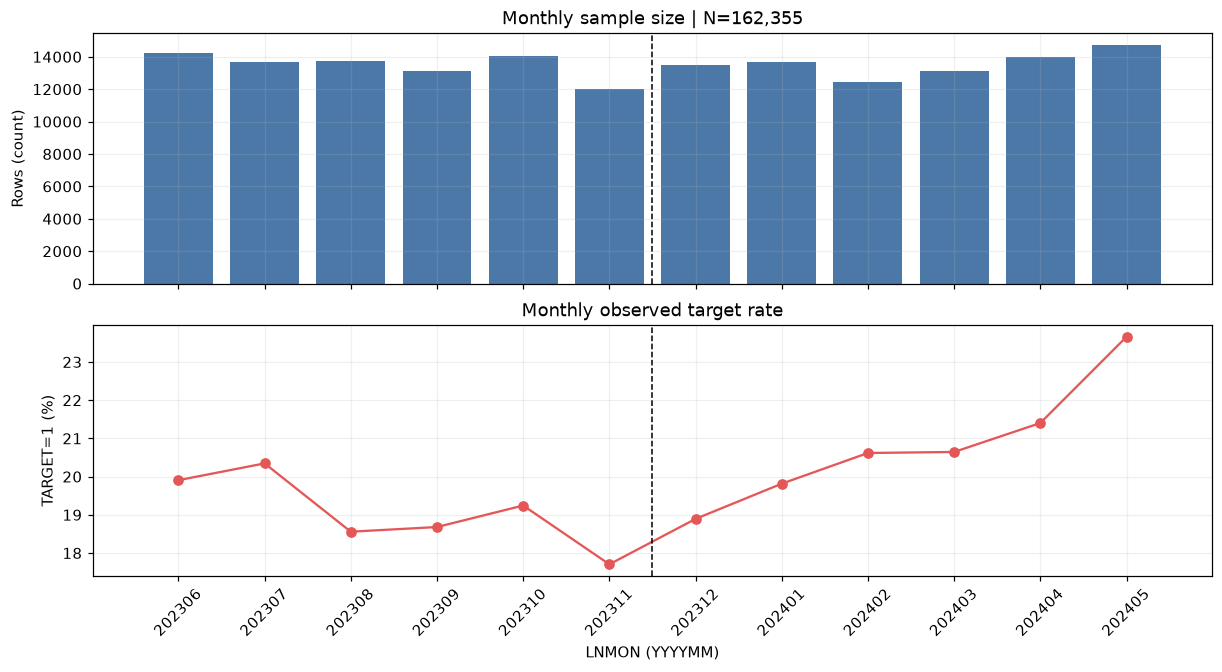

**관찰·해석.** 월별 표본은 12,031~14,713행으로 최대/최소 1.22배이고, 관찰된 양성 비율은 17.70~23.66%다. 첫 달 19.91%에서 마지막 달 23.66%로 변했다. 이 차이에는 실제 시간 변화뿐 아니라 추출·언더샘플링 방식의 월별 차이도 영향을 줄 수 있다.

In [4]:
monthly = df.groupby("LNMON", observed=True)["TARGET"].agg(n="size", target_1="sum", rate="mean").reindex(all_months)
monthly["rate_pct"] = 100*monthly["rate"]
display(monthly[["n", "target_1", "rate_pct"]].round(2).rename(columns={"n":"rows", "target_1":"TARGET=1 rows", "rate_pct":"TARGET=1 (%)"}))
month_to_pair = {m: f"{all_months[i//2*2]}–{all_months[min(i//2*2+1,len(all_months)-1)]}" for i,m in enumerate(all_months)}
two_month = df.groupby(df["LNMON"].map(month_to_pair))["TARGET"].agg(n="size", target_1="sum", rate="mean")
two_month = two_month.reindex(list(dict.fromkeys(month_to_pair[m] for m in all_months)))
display(two_month.assign(**{"TARGET=1 (%)": lambda x: (100*x["rate"]).round(2)})[["n", "target_1", "TARGET=1 (%)"]].rename(columns={"n":"rows", "target_1":"TARGET=1 rows"}))
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
x = np.arange(len(monthly))
ax[0].bar(x, monthly["n"], color="#4C78A8")
ax[0].set_ylabel("Rows (count)")
ax[0].set_title(f"Monthly sample size | N={len(df):,}")
ax[1].plot(x, monthly["rate_pct"], marker="o", color="#E45756")
ax[1].set_ylabel("TARGET=1 (%)")
ax[1].set_xlabel("LNMON (YYYYMM)")
ax[1].set_title("Monthly observed target rate")
ax[1].set_xticks(x, all_months, rotation=45)
for a in ax: a.axvline(5.5, color="black", linestyle="--", linewidth=1)
plt.show()
n_min, n_max = monthly["n"].min(), monthly["n"].max()
r_min, r_max = monthly["rate_pct"].min(), monthly["rate_pct"].max()
display(Markdown(f"**관찰·해석.** 월별 표본은 {n_min:,}~{n_max:,}행으로 최대/최소 {n_max/n_min:.2f}배이고, "
                 f"관찰된 양성 비율은 {r_min:.2f}~{r_max:.2f}%다. "
                 f"첫 달 {monthly['rate_pct'].iloc[0]:.2f}%에서 마지막 달 {monthly['rate_pct'].iloc[-1]:.2f}%로 변했다. "
                 "이 차이에는 실제 시간 변화뿐 아니라 추출·언더샘플링 방식의 월별 차이도 영향을 줄 수 있다."))

## 4. 결측과 특수값 — 전체 변수

**질문.** 어느 변수에서 결측이 많고 월별로 어떻게 달라지는가? 결측 여부의 target 건수·비율은 어떤가?

**표·그래프.** 전체·월별 결측률은 모든 변수에 대해 계산한다. 아래 화면에는 읽기 쉬운 일부 표와 히트맵을 보이고, 모든 변수의 월별·2개월별 `결측 / 관측` target 집계는 뒤에서 별도 CSV로 저장한다. 결측이 높다는 이유로 변수를 제외하지 않는다.

,variable,missing_n,missing_pct,TARGET=1 if missing n,TARGET=1 if missing %,observed_n,TARGET=1 if observed %,gap pp
53,AS1C30103,161655,99.57,32329,20.00,700,20.29,-0.29
100,DA1000104,160784,99.03,31644,19.68,1571,52.64,-32.96
63,ASCD30135,159678,98.35,31905,19.98,2677,21.14,-1.16
54,AS1C30104,159479,98.23,31869,19.98,2876,20.93,-0.95
125,D2Z000078,159207,98.06,31189,19.59,3148,40.72,-21.13
123,D2Z000071,159204,98.06,31189,19.59,3151,40.69,-21.09
124,D2Z000072,159204,98.06,31189,19.59,3151,40.69,-21.09
86,D10187D00,152452,93.90,29406,19.29,9903,30.95,-11.66
64,ASCD30137,152404,93.87,30662,20.12,9951,18.18,1.94
115,DUN000028,151658,93.41,28892,19.05,10697,33.46,-14.41


,variable,missing_n,missing_pct,TARGET=1 if missing n,TARGET=1 if missing %,observed_n,TARGET=1 if observed %,gap pp
100,DA1000104,160784,99.03,31644,19.68,1571,52.64,-32.96
125,D2Z000078,159207,98.06,31189,19.59,3148,40.72,-21.13
124,D2Z000072,159204,98.06,31189,19.59,3151,40.69,-21.09
123,D2Z000071,159204,98.06,31189,19.59,3151,40.69,-21.09
115,DUN000028,151658,93.41,28892,19.05,10697,33.46,-14.41
73,UA1040003,134798,83.03,24161,17.92,27557,30.16,-12.23
86,D10187D00,152452,93.90,29406,19.29,9903,30.95,-11.66
392,C1Z001474,243,0.15,76,31.28,162112,19.98,11.29
386,C1Z001358,399,0.25,123,30.83,161956,19.97,10.85
385,C1Z001340,425,0.26,128,30.12,161930,19.97,10.14


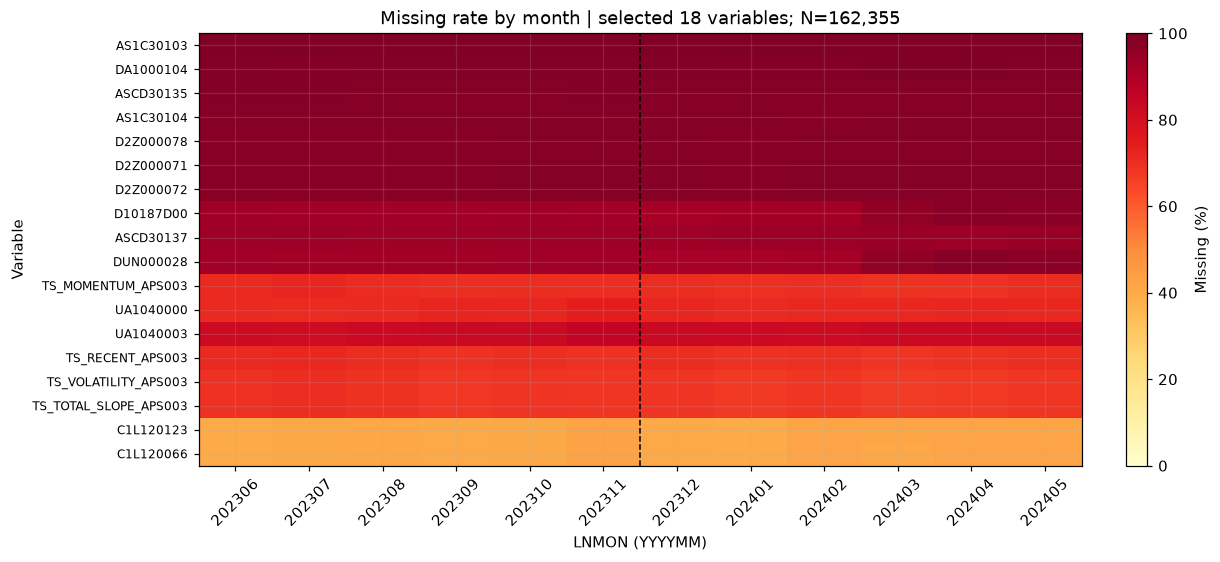

**관찰·해석.** 결측이 50% 이상인 열은 28개다. `missing_stats`와 `monthly_missing`에 모든 변수의 전체·월별 결측률이 들어 있다. 결측군의 비율 차이는 표본 수를 함께 보고 판단해야 한다. 결측 이유와 값의 생성 규칙은 정의서 확인이 필요하다.

In [5]:
missing_rate = df[feature_cols].isna().mean()
missing_count = df[feature_cols].isna().sum()
positive_missing = df.loc[df.TARGET.eq(1), feature_cols].isna().sum()
total_positive = int(df.TARGET.sum())
missing_stats = pd.DataFrame({"variable": feature_cols, "missing_n": missing_count.values,
                              "missing_pct": (100*missing_rate.values),
                              "TARGET=1 if missing n": positive_missing.values})
missing_stats["TARGET=1 if missing %"] = np.where(missing_stats.missing_n>0,
    100*missing_stats["TARGET=1 if missing n"]/missing_stats.missing_n, np.nan)
missing_stats["observed_n"] = len(df)-missing_stats.missing_n
missing_stats["TARGET=1 if observed %"] = np.where(missing_stats.observed_n>0,
    100*(total_positive-missing_stats["TARGET=1 if missing n"])/missing_stats.observed_n, np.nan)
missing_stats["gap pp"] = missing_stats["TARGET=1 if missing %"]-missing_stats["TARGET=1 if observed %"]
display(missing_stats.sort_values("missing_pct",ascending=False).head(15).round(2))
valid_missing = missing_stats[(missing_stats.missing_n>=100) & (missing_stats.observed_n>=100)]
display(valid_missing.reindex(valid_missing["gap pp"].abs().sort_values(ascending=False).index).head(12).round(2))
monthly_missing = pd.DataFrame({m: df.loc[df.LNMON.eq(m), feature_cols].isna().mean() for m in all_months}).T
selected_missing = pd.concat([missing_rate.sort_values(ascending=False).head(10),
                              (monthly_missing.max()-monthly_missing.min()).sort_values(ascending=False).head(10)]).index.drop_duplicates()[:18]
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
im = ax.imshow(100*monthly_missing[selected_missing].T.to_numpy(), aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
ax.set_yticks(np.arange(len(selected_missing)), selected_missing, fontsize=8)
ax.set_xticks(np.arange(len(all_months)), all_months, rotation=45)
ax.set_xlabel("LNMON (YYYYMM)"); ax.set_ylabel("Variable")
ax.set_title(f"Missing rate by month | selected {len(selected_missing)} variables; N={len(df):,}")
ax.axvline(5.5, color="black", linestyle="--", linewidth=1)
fig.colorbar(im, ax=ax, label="Missing (%)")
plt.show()
display(Markdown(f"**관찰·해석.** 결측이 50% 이상인 열은 {(missing_rate>=.5).sum()}개다. "
                 "`missing_stats`와 `monthly_missing`에 모든 변수의 전체·월별 결측률이 들어 있다. "
                 "결측군의 비율 차이는 표본 수를 함께 보고 판단해야 한다. 결측 이유와 값의 생성 규칙은 정의서 확인이 필요하다."))

### 모든 `SV_FLAG`와 원본 결측의 교차 점검

**질문.** `flag=1`일 때 원본이 결측인가? 반대로 **원본 결측인데 `flag=0`인 행**은 얼마나 되는가?

**표.** 모든 플래그를 검사하며 0·1 이외 값과 상수 플래그도 감사 결과에 남긴다. 접미사는 코드값 *후보*로 비교할 뿐 의미를 확정하지 않는다.

In [6]:
flag_cols = [c for c in feature_cols if "_SV_FLAG_" in c]
flag_records = []
for flag in flag_cols:
    base, suffix = flag.split("_SV_FLAG_", 1)
    f = pd.to_numeric(df[flag], errors="coerce")
    source_exists = base in df.columns
    source_missing = df[base].isna() if source_exists else pd.Series(False, index=df.index)
    f0, f1 = f.eq(0).fillna(False), f.eq(1).fillna(False)
    other = ~(f0 | f1)
    flag_records.append({
        "flag":flag, "base":base, "suffix_code_candidate":suffix,
        "source_exists":source_exists, "flag_constant":bool(flag in constants),
        "flag_0_n":int(f0.sum()), "flag_1_n":int(f1.sum()), "flag_other_or_missing_n":int(other.sum()),
        "base_missing_n":int(source_missing.sum()) if source_exists else np.nan,
        "flag_1_base_missing_n":int((f1 & source_missing).sum()) if source_exists else np.nan,
        "flag_1_base_observed_n":int((f1 & ~source_missing).sum()) if source_exists else np.nan,
        "flag_0_base_missing_n":int((f0 & source_missing).sum()) if source_exists else np.nan,
        "flag_0_base_observed_n":int((f0 & ~source_missing).sum()) if source_exists else np.nan,
        "flag_other_base_missing_n":int((other & source_missing).sum()) if source_exists else np.nan,
        "base_missing_if_flag_1_pct":100*source_missing[f1].mean() if source_exists and f1.any() else np.nan,
        "flag_0_if_base_missing_pct":100*f0[source_missing].mean() if source_exists and source_missing.any() else np.nan,
    })
flag_audit = pd.DataFrame(flag_records)
flag_audit.to_csv("kcb_flag_missing_audit.csv", index=False, encoding="utf-8-sig")
display(pd.DataFrame({"measure":["all SV_FLAG columns", "constant flags", "missing source columns",
                                  "flags with flag=0 while source missing"],
                      "n":[len(flag_audit),int(flag_audit.flag_constant.sum()),
                           int((~flag_audit.source_exists).sum()),int((flag_audit.flag_0_base_missing_n>0).sum())]}))
display(flag_audit.sort_values("flag_0_base_missing_n", ascending=False).head(12)[
    ["flag","flag_constant","flag_0_n","flag_1_n","base_missing_n",
     "flag_1_base_missing_n","flag_0_base_missing_n","flag_0_if_base_missing_pct"]].round(2))
display(Markdown("**관찰·해석.** `flag_0_base_missing_n`이 양수이면 이 플래그 하나로 원본 결측 전체를 설명할 수 없다. "
                 "전체 88개 결과는 `kcb_flag_missing_audit.csv`에 있으며, 접미사의 생성 의미는 정의서가 필요하다."))

,measure,n
0,all SV_FLAG columns,88
1,constant flags,9
2,missing source columns,0
3,flags with flag=0 while source missing,44


,flag,flag_constant,flag_0_n,flag_1_n,base_missing_n,flag_1_base_missing_n,flag_0_base_missing_n,flag_0_if_base_missing_pct
79,DA1000104_SV_FLAG_0_0,True,162355,0,160784,0,160784,100.00
74,D10187D00_SV_FLAG_0_0,False,162172,183,152452,183,152269,99.88
80,DUN000028_SV_FLAG_999999999_0,False,162212,143,151658,143,151515,99.91
17,AS1360004_SV_FLAG_M88888888_0,False,162331,24,108998,24,108974,99.98
19,AS1360006_SV_FLAG_M88888888_0,False,162331,24,104280,24,104256,99.98
34,C1L120123_SV_FLAG_9999999_9,False,162338,17,66748,17,66731,99.97
32,C1L120066_SV_FLAG_9999999_9,True,162355,0,66731,0,66731,100.00
44,C1L120292_SV_FLAG_9999999_9,False,162352,3,28595,3,28592,99.99
40,C1L120255_SV_FLAG_9999999_9,False,162056,299,28891,299,28592,98.97
42,C1L120256_SV_FLAG_9999999_9,False,162095,260,28852,260,28592,99.10


**관찰·해석.** `flag_0_base_missing_n`이 양수이면 이 플래그 하나로 원본 결측 전체를 설명할 수 없다. 전체 88개 결과는 `kcb_flag_missing_audit.csv`에 있으며, 접미사의 생성 의미는 정의서가 필요하다.

## 5. 전체 558개 변수 감사 및 구간 규칙

**질문.** 어떤 변수든 이름으로 찾았을 때 구조·희소성·결측·target 관계·시간 변화를 확인할 수 있는가?

**방법.** 모든 변수에 동일한 *감사 항목*을 계산한다. 수치형 구간은 값 구조에 따라 다르게 만든다: 고유값 12개 이하는 값별 범주, 0이나 다른 한 값이 탐색 기간 관측치의 50% 이상을 차지하면서 나머지가 충분히 연속적이면 그 값을 별도 구간으로 두고 나머지를 최대 4분위로 나눈다. 그 외 연속형은 최대 5분위다. 결측은 늘 별도 구간이다. 범주형은 모든 관측 범주를 유지한다. 구간 경계와 적용 규칙은 CSV에 기록한다. 이 규칙은 EDA 표현 방식이지 변수 의미나 채택 여부의 판정이 아니다.

In [7]:
discovery = df.loc[train_mask]
months = all_months
month_index = {m:i for i,m in enumerate(months)}
month_ix = df.LNMON.map(month_index).to_numpy(dtype=np.int16)
y = df.TARGET.to_numpy(dtype=np.int8)
pair_labels = [f"{months[i]}–{months[i+1]}" for i in range(0,12,2)]
min_interpret_n = max(100, int(.005*len(discovery)))

def make_bins(train, full):
    # 반환: 전체 기간 구간 라벨, 순서, 규칙, 경계 설명. 기준은 train만 사용.
    t = train
    if pd.api.types.is_numeric_dtype(t):
        z = pd.to_numeric(t,errors="coerce").astype("float64")
        observed = z.dropna()
        unique_n = observed.nunique()
        if unique_n > 12:
            most_common = observed.value_counts().index[0]
            most_share = float(observed.eq(most_common).mean())
            atom = float(most_common) if most_share >= .5 and observed[observed.ne(most_common)].nunique()>12 else None
            rest = observed[observed.ne(atom)] if atom is not None else observed
            q = 4 if atom is not None else 5
            edges = np.unique(np.quantile(rest.to_numpy(), np.linspace(0,1,q+1)))
            if len(edges)>2:
                cut_edges=edges.copy(); cut_edges[0]=-np.inf; cut_edges[-1]=np.inf
                labels=[f"{'non-atom ' if atom is not None else ''}Q{i+1}" for i in range(len(edges)-1)]
                full_num=pd.to_numeric(full,errors="coerce").astype("float64")
                group=pd.cut(full_num,bins=cut_edges,labels=labels,include_lowest=True).astype("string")
                if atom is not None:
                    atom_label="0" if atom==0 else f"dominant={atom:.8g}"
                    group=group.mask(full_num.eq(atom),atom_label)
                    labels=[atom_label]+labels
                group=group.fillna("Missing")
                edges_text="; ".join(f"{labels[(1 if atom is not None else 0)+i]}: {edges[i]:.8g}..{edges[i+1]:.8g} (outer tails included)" for i in range(len(edges)-1))
                rule="dominant_atom_plus_nonatom_quantiles" if atom is not None else "quantiles"
                return group,labels+["Missing"],rule,edges_text
    full_str=full.astype("string").fillna("Missing")
    train_str=t.astype("string").fillna("Missing")
    levels=sorted(train_str.unique().tolist())
    # 뒤 기간의 새 범주도 명시적으로 남긴다. 탐색 기간 구간은 바뀌지 않는다.
    unseen=~full_str.isin(levels)
    if unseen.any():
        full_str=full_str.where(~unseen,"Unseen after discovery")
        levels.append("Unseen after discovery")
    if "Missing" not in levels: levels.append("Missing")
    return full_str,levels,"exact_categories","exact observed values in discovery; unseen later values separate"

def period_rows(variable, group_name, rule, levels, counts, positives, period_type, labels):
    out=[]
    for j,period in enumerate(labels):
        total=int(counts[j].sum())
        for k,bin_name in enumerate(levels):
            n=int(counts[j,k]); pos=int(positives[j,k])
            out.append({"variable":variable,"variable_group":group_name,"bin_rule":rule,
                        "period_type":period_type,"period":str(period),"bin":bin_name,
                        "n":n,"target_1_n":pos,"target_1_pct":100*pos/n if n else np.nan,
                        "period_n":total,"bin_share_pct":100*n/total if total else np.nan,
                        "count_note":"0 rows" if n==0 else ("small (<30)" if n<30 else "")})
    return out

audit_rows=[]; bin_rows=[]; missing_rows=[]
for c in feature_cols:
    s=df[c]; tr=discovery[c]; group_name=prefix(c)
    labels_all, levels, rule, boundary=make_bins(tr,s)
    codes=pd.Categorical(labels_all,categories=levels).codes
    assert (codes>=0).all(), c
    k=len(levels)
    n_month=np.bincount(month_ix*k+codes,minlength=12*k).reshape(12,k)
    p_month=np.bincount(month_ix*k+codes,weights=y,minlength=12*k).reshape(12,k).astype(np.int64)
    n_two=n_month.reshape(6,2,k).sum(axis=1)
    p_two=p_month.reshape(6,2,k).sum(axis=1)
    n_six=np.stack([n_month[:6].sum(axis=0),n_month[6:].sum(axis=0)])
    p_six=np.stack([p_month[:6].sum(axis=0),p_month[6:].sum(axis=0)])
    bin_rows.extend(period_rows(c,group_name,rule,levels,n_month,p_month,"month",months))
    bin_rows.extend(period_rows(c,group_name,rule,levels,n_two,p_two,"two_month",pair_labels))
    bin_rows.extend(period_rows(c,group_name,rule,levels,n_six,p_six,"six_month",["discovery","check"]))

    miss=s.isna().to_numpy(dtype=bool)
    mn=np.bincount(month_ix,weights=miss,minlength=12).astype(np.int64)
    mp=np.bincount(month_ix,weights=miss*y,minlength=12).astype(np.int64)
    alln=monthly.n.to_numpy(dtype=np.int64); allp=monthly.target_1.to_numpy(dtype=np.int64)
    for period_type,n_arr,p_arr,m_arr,mp_arr,periods in [
        ("month",alln,allp,mn,mp,months),
        ("two_month",alln.reshape(6,2).sum(1),allp.reshape(6,2).sum(1),mn.reshape(6,2).sum(1),mp.reshape(6,2).sum(1),pair_labels),
        ("six_month",np.array([alln[:6].sum(),alln[6:].sum()]),np.array([allp[:6].sum(),allp[6:].sum()]),
         np.array([mn[:6].sum(),mn[6:].sum()]),np.array([mp[:6].sum(),mp[6:].sum()]),["discovery","check"])]:
        for j,period in enumerate(periods):
            for state,nval,pval in [("missing",int(m_arr[j]),int(mp_arr[j])),
                                    ("observed",int(n_arr[j]-m_arr[j]),int(p_arr[j]-mp_arr[j]))]:
                missing_rows.append({"variable":c,"variable_group":group_name,"period_type":period_type,
                                     "period":str(period),"state":state,"n":nval,"target_1_n":pval,
                                     "target_1_pct":100*pval/nval if nval else np.nan,
                                     "period_n":int(n_arr[j]),"state_share_pct":100*nval/n_arr[j],
                                     "count_note":"0 rows" if nval==0 else ("small (<30)" if nval<30 else "")})

    train_n=n_six[0]; train_p=p_six[0]
    populated=train_n>0; adequate=train_n>=min_interpret_n
    rates=np.divide(train_p,train_n,out=np.full(k,np.nan),where=train_n>0)
    if populated.sum()<2:
        status="계산 불가"; reasons=["탐색 기간의 유효 구간이 1개 이하"]
    else:
        reasons=[]
        if adequate.sum()<2: reasons.append(f"{min_interpret_n}행 이상인 구간이 2개 미만")
        if (populated & ~adequate).any(): reasons.append("작은 구간 존재")
        if miss.mean()>=.8: reasons.append("결측률 80% 이상")
        if dominant_share[c]>=.995: reasons.append("최빈값 비중 99.5% 이상")
        status="해석 주의" if reasons else "계산 가능"
    # 기간별 분포 폭, 충분한 건수의 구간별 월 양성률 폭을 모두 기록한다.
    month_share=n_month/n_month.sum(axis=1)[:,None]
    share_range=100*float(np.max(np.ptp(month_share,axis=0)))
    monthly_rate=np.divide(100*p_month,n_month,out=np.full(n_month.shape,np.nan,dtype=float),where=n_month>=30)
    rate_ranges=[np.ptp(monthly_rate[np.isfinite(monthly_rate[:,j]),j]) for j in range(k) if np.isfinite(monthly_rate[:,j]).sum()>=2]
    observed=s.notna()
    numeric=pd.api.types.is_numeric_dtype(s)
    if numeric:
        vals=pd.to_numeric(s,errors="coerce").dropna().to_numpy(dtype="float64")
        quant=np.quantile(vals,[.01,.05,.25,.5,.75,.95,.99]) if len(vals) else [np.nan]*7
        minval,maxval=(float(np.min(vals)),float(np.max(vals))) if len(vals) else (np.nan,np.nan)
        zero_n=int(np.sum(vals==0))
    else:
        quant=[np.nan]*7; minval=maxval=np.nan; zero_n=int(s.astype("string").eq("0").sum())
    audit_rows.append({"variable":c,"variable_group":group_name,"dtype":str(s.dtype),
        "unique_including_missing":int(distinct[c]),"constant":bool(c in constants),
        "dominant_share_pct":100*dominant_share[c],"zero_n":zero_n,"zero_share_pct":100*zero_n/len(df),
        "missing_n":int(miss.sum()),"missing_pct":100*miss.mean(),
        "monthly_missing_range_pp":float(100*np.ptp(mn/alln)),
        "observed_n":int(observed.sum()),"observed_target_1_n":int(df.loc[observed,"TARGET"].sum()),
        "observed_target_1_pct":100*df.loc[observed,"TARGET"].mean() if observed.any() else np.nan,
        "all_target_1_n":int(y.sum()),"all_target_1_pct":100*y.mean(),
        "min":minval,"p01":quant[0],"p05":quant[1],"p25":quant[2],"p50":quant[3],
        "p75":quant[4],"p95":quant[5],"p99":quant[6],"max":maxval,
        "bin_rule":rule,"bin_count_including_missing":k,"bin_boundaries":boundary,
        "discovery_populated_bins":int(populated.sum()),"discovery_small_bins":int((populated & ~adequate).sum()),
        "discovery_min_bin_n":int(train_n[populated].min()) if populated.any() else 0,
        "discovery_rate_gap_adequate_pp":100*float(np.ptp(rates[adequate])) if adequate.sum()>=2 else np.nan,
        "monthly_max_bin_share_range_pp":share_range,
        "monthly_max_bin_target_rate_range_pp":float(max(rate_ranges)) if rate_ranges else np.nan,
        "analysis_status":status,"status_reason":"; ".join(reasons) if reasons else "—"})

audit=pd.DataFrame(audit_rows)
bin_detail=pd.DataFrame(bin_rows)
missing_detail=pd.DataFrame(missing_rows)
assert len(audit)==len(feature_cols)==558 and audit.variable.is_unique
assert set(audit.variable)==set(feature_cols)
print(f"Audited {len(audit)} variables; bin detail {len(bin_detail):,} rows; missing detail {len(missing_detail):,} rows")

Audited 558 variables; bin detail 69,020 rows; missing detail 22,320 rows


### 변수군별 분포와 전체 감사표 검색

**질문.** 변수군 전체에서 결측·희소성·target 관계·월별 변화의 분포가 어떠한가?

**표.** 평균 하나 대신 중앙값과 90백분위수, 계산 상태별 건수를 보인다. `audit`은 메모리의 전체 558행 표이며, 저장한 CSV에서 변수명으로 검색할 수 있다.

In [8]:
def p90(x): return x.quantile(.9)
group_summary=audit.groupby("variable_group",dropna=False).agg(
    variables=("variable","size"),constants=("constant","sum"),
    median_missing_pct=("missing_pct","median"),p90_missing_pct=("missing_pct",p90),
    median_dominant_pct=("dominant_share_pct","median"),p90_dominant_pct=("dominant_share_pct",p90),
    median_zero_pct=("zero_share_pct","median"),
    median_target_gap_pp=("discovery_rate_gap_adequate_pp","median"),p90_target_gap_pp=("discovery_rate_gap_adequate_pp",p90),
    median_monthly_missing_range_pp=("monthly_missing_range_pp","median"),
    median_monthly_bin_share_range_pp=("monthly_max_bin_share_range_pp","median"),
    median_monthly_bin_rate_range_pp=("monthly_max_bin_target_rate_range_pp","median")
).reset_index()
for status in ["계산 가능","해석 주의","계산 불가"]:
    group_summary[status]=audit.assign(x=audit.analysis_status.eq(status).astype(int)).groupby("variable_group").x.sum().reindex(group_summary.variable_group).to_numpy()
group_summary=group_summary.sort_values("variables",ascending=False)
display(Markdown("**변수군 구조·결측·희소성 (전체 변수)**"))
display(group_summary[["variable_group","variables","constants","median_missing_pct","p90_missing_pct",
                       "median_dominant_pct","p90_dominant_pct","median_zero_pct","계산 가능","해석 주의","계산 불가"]].round(2))
display(Markdown("**변수군 target 관계·월별 변화 (전체 변수)**"))
display(group_summary[["variable_group","variables","median_target_gap_pp","p90_target_gap_pp",
                       "median_monthly_missing_range_pp","median_monthly_bin_share_range_pp",
                       "median_monthly_bin_rate_range_pp"]].round(2))
display(audit[audit.variable.isin(["TS_VOLATILITY_CPS001","DA1000104","C20172001","L2Z000142"])][
    ["variable","variable_group","dtype","unique_including_missing","dominant_share_pct","zero_share_pct",
     "missing_pct","observed_n","observed_target_1_pct","bin_rule","analysis_status","status_reason"]].round(2))
print("Search example: audit.loc[audit.variable.str.contains('CPS001', regex=False)].head(10)")
display(audit.loc[audit.variable.str.contains("CPS001",regex=False),
                  ["variable","bin_rule","missing_pct","analysis_status","status_reason"]].head(10).round(2))
display(Markdown("**관찰·해석.** 변수군 표는 해당 군의 **전체 변수**를 사용한다. 작은 집단이나 고결측에 대한 표시는 "
                 "해석 경고이며, 변수를 남기거나 버리는 결정이 아니다."))

**변수군 구조·결측·희소성 (전체 변수)**

,variable_group,variables,constants,median_missing_pct,p90_missing_pct,median_dominant_pct,p90_dominant_pct,median_zero_pct,계산 가능,해석 주의,계산 불가
3,C,124,0,0.00,17.61,35.85,85.47,11.40,81,43,0
11,L,95,0,0.00,0.00,36.86,84.53,20.87,35,60,0
14,SV_FLAG,88,9,0.00,0.00,99.83,100.00,99.83,38,40,10
15,TS_,77,0,0.00,17.74,62.01,83.79,28.22,75,2,0
5,DA,33,0,0.00,0.00,99.46,99.81,99.46,0,33,0
4,D,31,0,0.00,93.90,98.97,100.00,98.97,5,25,1
1,AS,30,0,0.00,86.12,86.06,98.32,68.65,16,14,0
8,DUN,16,0,0.00,0.00,98.65,99.79,98.65,2,14,0
16,U,14,0,0.00,0.02,1.27,10.05,0.09,11,3,0
0,AL,14,0,0.01,0.02,50.70,66.84,0.00,1,13,0


**변수군 target 관계·월별 변화 (전체 변수)**

,variable_group,variables,median_target_gap_pp,p90_target_gap_pp,median_monthly_missing_range_pp,median_monthly_bin_share_range_pp,median_monthly_bin_rate_range_pp
3,C,124,5.49,12.29,0.00,2.40,8.96
11,L,95,7.68,13.26,0.00,1.91,19.33
14,SV_FLAG,88,2.55,17.91,0.00,0.13,5.98
15,TS_,77,7.45,12.76,0.00,3.13,8.44
5,DA,33,38.38,40.55,0.00,0.36,24.29
4,D,31,17.94,22.27,0.00,0.62,15.97
1,AS,30,7.19,9.92,0.00,0.86,10.18
8,DUN,16,27.93,29.22,0.00,1.01,24.94
16,U,14,8.58,9.60,0.00,2.55,6.93
0,AL,14,16.02,24.35,0.04,3.16,16.20


,variable,variable_group,dtype,unique_including_missing,dominant_share_pct,zero_share_pct,missing_pct,observed_n,observed_target_1_pct,bin_rule,analysis_status,status_reason
67,C20172001,C,int16,13800,0.14,0.00,0.00,162355,20.00,quantiles,계산 가능,—
70,L2Z000142,L,int16,13719,0.14,0.00,0.00,162355,20.00,quantiles,계산 가능,—
100,DA1000104,DA,Int32,649,99.03,0.00,99.03,1571,52.64,quantiles,해석 주의,404행 이상인 구간이 2개 미만; 작은 구간 존재; 결측률 80% 이상
395,TS_VOLATILITY_CPS001,TS_,float32,1410,85.98,85.98,0.00,162355,20.00,dominant_atom_plus_nonatom_quantiles,계산 가능,—


Search example: audit.loc[audit.variable.str.contains('CPS001', regex=False)].head(10)


,variable,bin_rule,missing_pct,analysis_status,status_reason
393,TS_RECENT_CPS001,dominant_atom_plus_nonatom_quantiles,0.0,계산 가능,—
394,TS_MOMENTUM_CPS001,dominant_atom_plus_nonatom_quantiles,0.0,계산 가능,—
395,TS_VOLATILITY_CPS001,dominant_atom_plus_nonatom_quantiles,0.0,계산 가능,—
396,TS_MAX_IN_3M_FLAG_CPS001,exact_categories,0.0,계산 가능,—
397,TS_TOTAL_SLOPE_CPS001,dominant_atom_plus_nonatom_quantiles,0.0,계산 가능,—


**관찰·해석.** 변수군 표는 해당 군의 **전체 변수**를 사용한다. 작은 집단이나 고결측에 대한 표시는 해석 경고이며, 변수를 남기거나 버리는 결정이 아니다.

## 6. 모든 변수의 target 관계와 시점별 상세 집계

**질문.** 앞 6개월에서 정한 구간마다 월별·연속 2개월별 표본 비중, 양성 건수, target 비율을 모두 확인할 수 있는가?

**표.** `bin_detail`에는 모든 558개 변수와 모든 구간의 월별 12개, 연속 2개월별 6개, 앞/뒤 6개월 2개 집계가 있다. 0행 구간도 남긴다. `target_1_pct`는 해당 구간의 행 기준이며 전체 월 비율 상승과 나란히 비교한다. 화면에는 값 구조 사례만 표시한다.

**TS_VOLATILITY_CPS001** — rule: `dominant_atom_plus_nonatom_quantiles`; non-atom Q1: 0.2..0.47609523 (outer tails included); non-atom Q2: 0.47609523..0.74610096 (outer tails included); non-atom Q3: 0.74610096..1.274101 (outer tails included); non-atom Q4: 1.274101..7.0493498 (outer tails included); discovery N=80,903

,bin,n,target_1_n,target_1_pct,bin_share_pct,count_note
56228,0,69361,11527,16.62,85.73,
56229,non-atom Q1,3258,702,21.55,4.03,
56230,non-atom Q2,2533,616,24.32,3.13,
56231,non-atom Q3,2872,986,34.33,3.55,
56232,non-atom Q4,2879,1629,56.58,3.56,
56233,Missing,0,0,NaN,0.00,0 rows


**C20172001** — rule: `quantiles`; Q1: 15..2283 (outer tails included); Q2: 2283..4040 (outer tails included); Q3: 4040..5803 (outer tails included); Q4: 5803..8328 (outer tails included); Q5: 8328..15315 (outer tails included); discovery N=80,903

,bin,n,target_1_n,target_1_pct,bin_share_pct,count_note
9568,Q1,16183,4357,26.92,20.00,
9569,Q2,16182,3831,23.67,20.00,
9570,Q3,16178,2907,17.97,20.00,
9571,Q4,16187,2370,14.64,20.01,
9572,Q5,16173,1995,12.34,19.99,
9573,Missing,0,0,NaN,0.00,0 rows


**AL012G017** — rule: `exact_categories`; exact observed values in discovery; unseen later values separate; discovery N=80,903

,bin,n,target_1_n,target_1_pct,bin_share_pct,count_note
3248,1,43757,6483,14.82,54.09,
3249,2,35125,8311,23.66,43.42,
3250,3,1826,601,32.91,2.26,
3251,4,148,50,33.78,0.18,
3252,5,29,11,37.93,0.04,small (<30)
3253,Missing,18,4,22.22,0.02,small (<30)


**시간 비교 예시: TS_VOLATILITY_CPS001** — 모든 구간의 2개월별 양성 건수·비율·비중

,period,bin,n,target_1_n,target_1_pct,bin_share_pct
56192,202306–202307,0,23734,4095,17.25,85.00
56193,202306–202307,non-atom Q1,1065,225,21.13,3.81
56194,202306–202307,non-atom Q2,898,239,26.61,3.22
56195,202306–202307,non-atom Q3,1056,375,35.51,3.78
56196,202306–202307,non-atom Q4,1168,684,58.56,4.18
56197,202306–202307,Missing,0,0,NaN,0.00
56198,202308–202309,0,23052,3711,16.10,85.71
56199,202308–202309,non-atom Q1,1129,245,21.70,4.20
56200,202308–202309,non-atom Q2,790,188,23.80,2.94
56201,202308–202309,non-atom Q3,972,330,33.95,3.61


Read all saved rows: pd.read_csv('kcb_target_bins_by_period.csv')
Filter example: show_variable_periods('TS_VOLATILITY_CPS001', 'month')


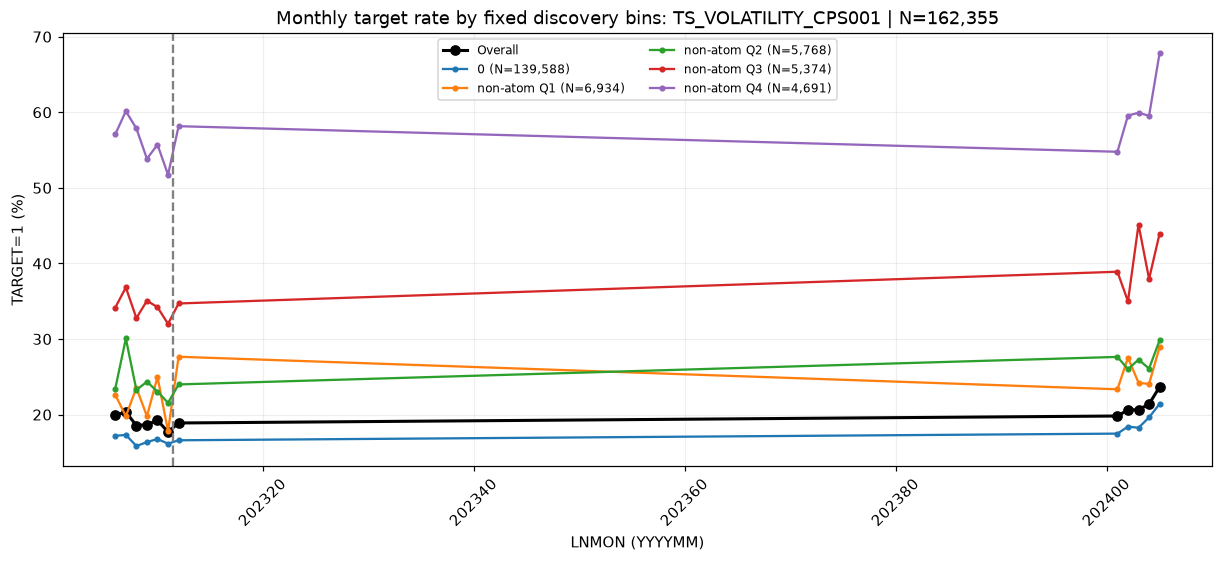

**관찰·해석.** 전체 target 비율과 각 고정 구간의 비율을 함께 읽는다. 한 구간의 월별 건수가 적으면 비율의 흔들림이 크며, 단일 분포 지표만으로 안정성을 판정하지 않는다.

In [9]:
for c in ["TS_VOLATILITY_CPS001","C20172001","AL012G017"]:
    a=audit.loc[audit.variable.eq(c)].iloc[0]
    discovery_bins=bin_detail[(bin_detail.variable==c)&(bin_detail.period_type=="six_month")&(bin_detail.period=="discovery")]
    display(Markdown(f"**{c}** — rule: `{a.bin_rule}`; {a.bin_boundaries}; discovery N={int(train_mask.sum()):,}"))
    display(discovery_bins[["bin","n","target_1_n","target_1_pct","bin_share_pct","count_note"]].round(2))

example="TS_VOLATILITY_CPS001"
display(Markdown(f"**시간 비교 예시: {example}** — 모든 구간의 2개월별 양성 건수·비율·비중"))
with pd.option_context("display.max_rows",40):
    display(bin_detail[(bin_detail.variable==example)&(bin_detail.period_type=="two_month")][
        ["period","bin","n","target_1_n","target_1_pct","bin_share_pct"]].round(2))

def show_variable_periods(name, period_type="month"):
    return bin_detail[(bin_detail.variable==name)&(bin_detail.period_type==period_type)].copy()
print("Read all saved rows: pd.read_csv('kcb_target_bins_by_period.csv')")
print("Filter example: show_variable_periods('TS_VOLATILITY_CPS001', 'month')")

# 각 구간의 비율 변화를 전체 월 비율과 같은 축에 놓는다. 그래프는 예시이며 CSV는 전 변수다.
case=bin_detail[(bin_detail.variable==example)&(bin_detail.period_type=="month")]
fig, ax=plt.subplots(figsize=(11,5),constrained_layout=True)
ax.plot(months,100*monthly.rate.to_numpy(),color="black",linewidth=2,marker="o",label="Overall")
for label,part in case.groupby("bin",sort=False):
    if label=="Missing" or part.n.sum()<100: continue
    ax.plot(part.period.astype(int),part.target_1_pct,marker=".",label=f"{label} (N={part.n.sum():,})")
ax.set_title(f"Monthly target rate by fixed discovery bins: {example} | N={len(df):,}")
ax.set_xlabel("LNMON (YYYYMM)");ax.set_ylabel("TARGET=1 (%)")
ax.axvline(202311.5,color="grey",linestyle="--")
ax.legend(fontsize=8,ncol=2);ax.tick_params(axis="x",rotation=45)
plt.show()
display(Markdown("**관찰·해석.** 전체 target 비율과 각 고정 구간의 비율을 함께 읽는다. "
                 "한 구간의 월별 건수가 적으면 비율의 흔들림이 크며, 단일 분포 지표만으로 안정성을 판정하지 않는다."))

### 결측 / 관측의 월별·2개월별 target 관계

**질문.** 고결측 변수의 결측군과 관측군이 월별·2개월별로 어떻게 다른가?

**표.** 같은 진단은 `missing_detail`의 모든 변수에 적용됐다. 아래 다섯 변수는 사례로 월별 12개와 연속 2개월별 6개 구간을 모두 보인다. 0행이면 비율은 빈값이다.

In [10]:
high_missing_cases=["DA1000104","D2Z000071","D2Z000072","D2Z000078","DUN000028"]
def missing_case_table(name, period_type):
    x=missing_detail[(missing_detail.variable==name)&(missing_detail.period_type==period_type)]
    return x.pivot(index="period",columns="state",values=["n","target_1_n","target_1_pct"]).round(2)
for c in high_missing_cases:
    display(Markdown(f"**{c}** — 월별, 이어서 연속 2개월별"))
    display(missing_case_table(c,"month"))
    display(missing_case_table(c,"two_month"))
print("Read all saved rows: pd.read_csv('kcb_missing_target_by_period.csv')")
display(Markdown("**관찰·해석.** 결측군과 관측군의 건수를 함께 본다. 관측군이 드문 변수에서는 큰 비율 차이도 불확실하다. "
                 "월별 추출 방식과 결측 생성 규칙이 확인되기 전까지 원인을 단정하지 않는다."))

**DA1000104** — 월별, 이어서 연속 2개월별

n          target_1_n          target_1_pct         
state   missing observed    missing observed      missing observed
period                                                            
202306  14093.0    159.0     2742.0     95.0        19.46    59.75
202307  13504.0    165.0     2697.0     84.0        19.97    50.91
202308  13626.0    131.0     2493.0     60.0        18.30    45.80
202309  12994.0    143.0     2383.0     71.0        18.34    49.65
202310  13905.0    152.0     2628.0     77.0        18.90    50.66
202311  11936.0     95.0     2084.0     46.0        17.46    48.42
202312  13377.0    136.0     2487.0     66.0        18.59    48.53
202401  13530.0    177.0     2638.0     78.0        19.50    44.07
202402  12309.0    151.0     2486.0     83.0        20.20    54.97
202403  13015.0     78.0     2662.0     41.0        20.45    52.56
202404  13898.0     68.0     2939.0     50.0        21.15    73.53
202405  14597.0    116.0     3405.0     76.0        23.33    65.52

n          target_1_n          target_1_pct         
state          missing observed    missing observed      missing observed
period                                                                   
202306–202307  27597.0    324.0     5439.0    179.0        19.71    55.25
202308–202309  26620.0    274.0     4876.0    131.0        18.32    47.81
202310–202311  25841.0    247.0     4712.0    123.0        18.23    49.80
202312–202401  26907.0    313.0     5125.0    144.0        19.05    46.01
202402–202403  25324.0    229.0     5148.0    124.0        20.33    54.15
202404–202405  28495.0    184.0     6344.0    126.0        22.26    68.48

**D2Z000071** — 월별, 이어서 연속 2개월별

n          target_1_n          target_1_pct         
state   missing observed    missing observed      missing observed
period                                                            
202306  13924.0    328.0     2683.0    154.0        19.27    46.95
202307  13366.0    303.0     2640.0    141.0        19.75    46.53
202308  13478.0    279.0     2437.0    116.0        18.08    41.58
202309  12879.0    258.0     2353.0    101.0        18.27    39.15
202310  13807.0    250.0     2596.0    109.0        18.80    43.60
202311  11797.0    234.0     2045.0     85.0        17.33    36.32
202312  13266.0    247.0     2467.0     86.0        18.60    34.82
202401  13421.0    286.0     2608.0    108.0        19.43    37.76
202402  12237.0    223.0     2484.0     85.0        20.30    38.12
202403  12851.0    242.0     2622.0     81.0        20.40    33.47
202404  13708.0    258.0     2878.0    111.0        21.00    43.02
202405  14470.0    243.0     3376.0    105.0        23.33    43.21

...

**DUN000028** — 월별, 이어서 연속 2개월별

n          target_1_n          target_1_pct         
state   missing observed    missing observed      missing observed
period                                                            
202306  13212.0   1040.0     2440.0    397.0        18.47    38.17
202307  12605.0   1064.0     2429.0    352.0        19.27    33.08
202308  12712.0   1045.0     2223.0    330.0        17.49    31.58
202309  12111.0   1026.0     2125.0    329.0        17.55    32.07
202310  13019.0   1038.0     2381.0    324.0        18.29    31.21
202311  11147.0    884.0     1872.0    258.0        16.79    29.19
202312  12379.0   1134.0     2215.0    338.0        17.89    29.81
202401  12573.0   1134.0     2354.0    362.0        18.72    31.92
202402  11446.0   1014.0     2220.0    349.0        19.40    34.42
202403  12540.0    553.0     2519.0    184.0        20.09    33.27
202404  13652.0    314.0     2850.0    139.0        20.88    44.27
202405  14262.0    451.0     3264.0    217.0        22.89    48.12

n          target_1_n          target_1_pct         
state          missing observed    missing observed      missing observed
period                                                                   
202306–202307  25817.0   2104.0     4869.0    749.0        18.86    35.60
202308–202309  24823.0   2071.0     4348.0    659.0        17.52    31.82
202310–202311  24166.0   1922.0     4253.0    582.0        17.60    30.28
202312–202401  24952.0   2268.0     4569.0    700.0        18.31    30.86
202402–202403  23986.0   1567.0     4739.0    533.0        19.76    34.01
202404–202405  27914.0    765.0     6114.0    356.0        21.90    46.54

Read all saved rows: pd.read_csv('kcb_missing_target_by_period.csv')


**관찰·해석.** 결측군과 관측군의 건수를 함께 본다. 관측군이 드문 변수에서는 큰 비율 차이도 불확실하다. 월별 추출 방식과 결측 생성 규칙이 확인되기 전까지 원인을 단정하지 않는다.

## 7. 전체 열의 정확한 중복과 변수군 내 유사성

**질문.** 완전히 같은 열은 어느 것인가? 높은 상관의 열은 실제 값이 얼마나 같은가?

**방법.** 558개 열 모두를 해시로 묶고 원본 값을 다시 비교한다. 유사성은 변수군 안의 수치형 열을 탐색 기간 최대 2만 행에서 Spearman 상관으로 탐색한다. |ρ|≥0.98인 쌍에는 전체 기간의 일치 행 수와 값 차이를 계산한다. 수치 코드의 순서가 업무상 의미 있는지는 알 수 없으므로 상관은 탐색 지표다. 어떤 열도 자동 삭제하지 않는다.

In [11]:
# 정확한 중복: 전 변수, 결측 위치까지 동일해야 한다.
signatures={}
for c in feature_cols:
    source=df[c]
    normalized=source.astype("float64") if pd.api.types.is_numeric_dtype(source) else source.astype("string")
    digest=hashlib.sha1(pd.util.hash_pandas_object(normalized,index=False).to_numpy(dtype="uint64").tobytes()).hexdigest()
    signatures.setdefault(digest,[]).append(c)
def columns_equal(a,b):
    x,y=df[a],df[b]
    x=x.astype("float64") if pd.api.types.is_numeric_dtype(x) else x.astype("string")
    y=y.astype("float64") if pd.api.types.is_numeric_dtype(y) else y.astype("string")
    matching=x.eq(y).fillna(False) | (x.isna() & y.isna())
    return bool(matching.all())
exact_groups=[]
for candidates in signatures.values():
    if len(candidates)<2: continue
    # 해시 충돌까지 대비해 실제 동일한 열끼리만 묶는다.
    remaining=candidates[:]
    while remaining:
        first=remaining.pop(0)
        group=[first]+[x for x in remaining if columns_equal(first,x)]
        remaining=[x for x in remaining if x not in group]
        if len(group)>1: exact_groups.append(group)
dup_rows=[]
for i,g in enumerate(exact_groups,1):
    for c in g: dup_rows.append({"duplicate_group":i,"variable":c,"representative":g[0],"group_size":len(g)})
exact_duplicates=pd.DataFrame(dup_rows,columns=["duplicate_group","variable","representative","group_size"])
audit["exact_duplicate_group"] = audit.variable.map(exact_duplicates.set_index("variable").duplicate_group) if len(exact_duplicates) else np.nan
audit["exact_duplicate_group_size"] = audit.variable.map(exact_duplicates.set_index("variable").group_size).fillna(1).astype(int) if len(exact_duplicates) else 1
display(pd.DataFrame({"measure":["feature columns checked","exact duplicate groups","columns in duplicate groups"],
                      "n":[len(feature_cols),len(exact_groups),len(exact_duplicates)]}))
display(exact_duplicates.groupby(["duplicate_group","representative","group_size"]).variable.apply(lambda s:", ".join(s.head(4))).reset_index(name="first members").head(12))

# 변수군별 상관. 전체 558열 상관행렬을 만들거나 화면에 출력하지 않는다.
corr_sample=df.loc[train_mask].sample(n=min(20_000,int(train_mask.sum())),random_state=2026)
similar=[]
for g,part in audit.groupby("variable_group"):
    numeric_cols=[c for c in part.variable if pd.api.types.is_numeric_dtype(df[c]) and c not in constants]
    if len(numeric_cols)<2: continue
    cor=corr_sample[numeric_cols].corr(method="spearman",min_periods=500)
    for i,a in enumerate(numeric_cols):
        for b in numeric_cols[i+1:]:
            rho=cor.loc[a,b]
            if not pd.notna(rho) or abs(rho)<.98: continue
            sa=pd.to_numeric(df[a],errors="coerce").to_numpy(dtype="float64",na_value=np.nan)
            sb=pd.to_numeric(df[b],errors="coerce").to_numpy(dtype="float64",na_value=np.nan)
            jointly=np.isfinite(sa)&np.isfinite(sb)
            differences=np.abs(sa[jointly]-sb[jointly])
            same=(sa==sb)|(np.isnan(sa)&np.isnan(sb))
            similar.append({"variable_group":g,"variable_1":a,"variable_2":b,
                            "sample_spearman_rho":rho,"joint_observed_n":int(jointly.sum()),
                            "exact_same_n_including_missing":int(same.sum()),
                            "exact_same_pct":100*same.mean(),
                            "different_n_including_missing":int((~same).sum()),
                            "median_abs_diff_joint":float(np.median(differences)) if len(differences) else np.nan,
                            "p90_abs_diff_joint":float(np.quantile(differences,.9)) if len(differences) else np.nan})
similar_pairs=pd.DataFrame(similar,columns=["variable_group","variable_1","variable_2","sample_spearman_rho",
                                    "joint_observed_n","exact_same_n_including_missing","exact_same_pct",
                                    "different_n_including_missing","median_abs_diff_joint","p90_abs_diff_joint"])
display(pd.DataFrame({"measure":["high-correlation within-group pairs (|rho|>=0.98)","groups with such pairs"],
                      "n":[len(similar_pairs),similar_pairs.variable_group.nunique()]}))
display(similar_pairs.reindex(similar_pairs.sample_spearman_rho.abs().sort_values(ascending=False).index).head(15).round(3))
display(Markdown("**관찰·해석.** 완전 동일과 높은 상관은 다른 개념이다. 값 차이·결측 위치를 함께 확인하며, "
                 "높은 상관만으로 변수의 삭제나 채택을 결정하지 않는다."))

,measure,n
0,feature columns checked,558
1,exact duplicate groups,22
2,columns in duplicate groups,85


,duplicate_group,representative,group_size,first members
0,1,D20110000,2,"D20110000, D2Z000067"
1,2,DA0D00013,4,"DA0D00013, DA0D00036, DA0D00037, DA0D00038"
2,3,DD0210X13,2,"DD0210X13, DD0210X16"
3,4,DDC001000,10,"DDC001000, C1L120066_SV_FLAG_9999999_9, C1Z001..."
4,5,D3011000K,4,"D3011000K, D3011000N, D3011000R, D30210000"
5,6,L2M000114,2,"L2M000114, L2M000138"
6,7,L2Z000262,2,"L2Z000262, L2Z000993"
7,8,L2Z000263,2,"L2Z000263, L2Z000990"
8,9,L2Z000265,2,"L2Z000265, L2Z000991"
9,10,L2Z000268,2,"L2Z000268, L2Z000976"


,measure,n
0,high-correlation within-group pairs (|rho|>=0.98),395
1,groups with such pairs,11


,variable_group,variable_1,variable_2,sample_spearman_rho,joint_observed_n,exact_same_n_including_missing,exact_same_pct,different_n_including_missing,median_abs_diff_joint,p90_abs_diff_joint
23,C,C1M1A8003,C1N1A8003,1.0,162355,162355,100.0,0,0.0,0.0
378,SV_FLAG,C1L120354_SV_FLAG_8888888_8,C1P000005_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
379,SV_FLAG,C1L120357_SV_FLAG_8888888_8,C1P000005_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
318,SV_FLAG,C1L120238_SV_FLAG_8888888_8,C1L120331_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
319,SV_FLAG,C1L120238_SV_FLAG_8888888_8,C1L120333_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
320,SV_FLAG,C1L120238_SV_FLAG_8888888_8,C1L120347_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
321,SV_FLAG,C1L120238_SV_FLAG_8888888_8,C1L120354_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
322,SV_FLAG,C1L120238_SV_FLAG_8888888_8,C1L120357_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
323,SV_FLAG,C1L120238_SV_FLAG_8888888_8,C1P000005_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0
324,SV_FLAG,C1L120250_SV_FLAG_8888888_8,C1L120255_SV_FLAG_8888888_8,1.0,162355,162355,100.0,0,0.0,0.0


**관찰·해석.** 완전 동일과 높은 상관은 다른 개념이다. 값 차이·결측 위치를 함께 확인하며, 높은 상관만으로 변수의 삭제나 채택을 결정하지 않는다.

### 서로 다른 접두어 사례: `C20172001`과 `L2Z000142`

**질문.** 두 열의 관측값은 얼마나 겹치며 어디에서 달라지는가?

**표·그래프.** 탐색 기간의 상관과 전체 기간의 정확한 일치·절대 차이 분포를 함께 표시한다. 값의 업무 단위가 같다는 정보가 없으므로 숫자 차이는 기록 차원의 비교다.

,measure,value
0,rows,162355.000
1,joint observed rows,162355.000
2,joint missing rows,0.000
3,exact equal rows (joint observed),140479.000
4,exact equal % (joint observed),86.526
5,Spearman rho (discovery),0.959
6,median absolute difference,0.000
7,p90 absolute difference,392.000
8,p99 absolute difference,4141.920


,rows,median,p90,exact_equal_pct
month,,,,
202306,14252,0.0,385.6,86.50
202307,13669,0.0,409.6,86.89
202308,13757,0.0,335.0,87.12
202309,13137,0.0,419.4,86.30
202310,14057,0.0,420.4,86.47
202311,12031,0.0,350.0,86.83
202312,13513,0.0,428.4,86.11
202401,13707,0.0,406.6,86.01
202402,12460,0.0,363.2,86.89


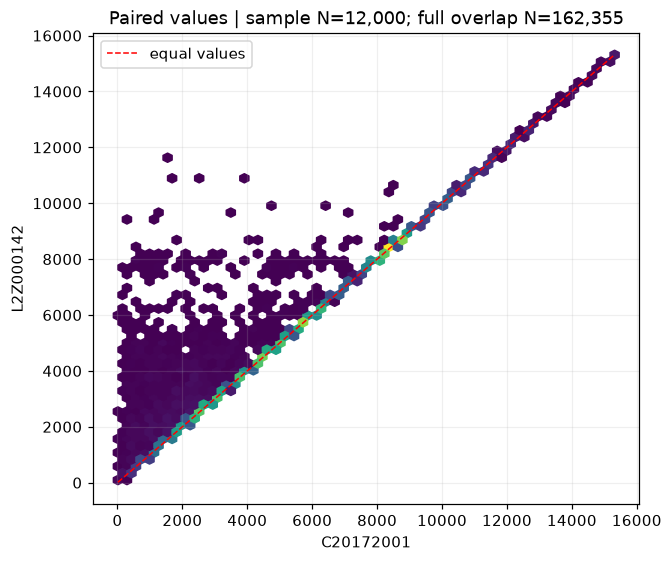

**관찰·해석.** 상관이 높아도 완전히 동일하지 않은 행과 차이의 크기를 별도로 확인한다. 변수 정의서 없이 두 값의 차이가 측정 방식 때문인지 해석할 수 없다.

In [12]:
a,b="C20172001","L2Z000142"
pair=df[[a,b,"LNMON"]].copy()
joint=pair[[a,b]].notna().all(axis=1)
pair_values=pair.loc[joint,[a,b]].astype("float64")
abs_difference=(pair_values[a]-pair_values[b]).abs()
pair_summary=pd.DataFrame({"measure":["rows", "joint observed rows", "joint missing rows", "exact equal rows (joint observed)",
                                       "exact equal % (joint observed)","Spearman rho (discovery)",
                                       "median absolute difference", "p90 absolute difference", "p99 absolute difference"],
                           "value":[len(df),int(joint.sum()),int(pair[[a,b]].isna().all(axis=1).sum()),
                                    int(pair_values[a].eq(pair_values[b]).sum()),
                                    100*pair_values[a].eq(pair_values[b]).mean(),
                                    discovery[[a,b]].corr(method="spearman").iloc[0,1],
                                    abs_difference.median(),abs_difference.quantile(.9),abs_difference.quantile(.99)]})
display(pair_summary.round(3))
monthly_pair=pd.DataFrame({"month":pair.loc[joint,"LNMON"],"abs_difference":abs_difference}).groupby("month").abs_difference.agg(
    rows="size",median="median",p90=lambda s:s.quantile(.9),exact_equal_pct=lambda s:100*s.eq(0).mean())
display(monthly_pair.round(2))
plot_sample=pair_values.sample(n=min(12_000,len(pair_values)),random_state=2026)
fig,ax=plt.subplots(figsize=(6,5),constrained_layout=True)
ax.hexbin(plot_sample[a],plot_sample[b],gridsize=55,mincnt=1,cmap="viridis")
lims=[min(plot_sample.min()),max(plot_sample.max())]
ax.plot(lims,lims,color="red",linestyle="--",linewidth=1,label="equal values")
ax.set_xlabel(a);ax.set_ylabel(b)
ax.set_title(f"Paired values | sample N={len(plot_sample):,}; full overlap N={len(pair_values):,}")
ax.legend();plt.show()
display(Markdown("**관찰·해석.** 상관이 높아도 완전히 동일하지 않은 행과 차이의 크기를 별도로 확인한다. "
                 "변수 정의서 없이 두 값의 차이가 측정 방식 때문인지 해석할 수 없다."))

## 8. 누수 점검 질문

**질문.** 값이 실제 예측 시점에 이미 존재했는가?

| 점검 질문 | 현재 결론 |
|---|---|
| `LNMON`은 기준 시점, 사건 발생월, 관찰 종료월 중 무엇인가? | **추가 확인 필요** |
| `TARGET` 사건 정의와 예측 기간은 무엇인가? | **추가 확인 필요** |
| 모든 `TS_...`의 계산 창이 해당 `LNMON` 이전에 끝나는가? 미래 월·월말 이후 갱신분이 섞였는가? | **추가 확인 필요** |
| 코드형 변수와 플래그가 예측 후 확정된 정보에서 파생됐는가? | **추가 확인 필요** |
| 반복 주체, 추출·언더샘플링 규칙이 월별로 달라지는가? | 식별자·생성 명세 부재로 **추가 확인 필요** |

자료의 통계적 관계만으로 누수를 확정하거나 배제할 수 없다. 변수 정의서, 생성 SQL, 원천 시각과 실제 사용 시점을 대조해야 한다.

## 9. 저장·포괄률 점검·해석

**질문.** 모든 558개 변수가 실제 산출물에 남았고, 계산 불가 사유가 설명되는가?

**표.** CSV는 모두 노트북 폴더에 저장한다. 558개 감사 행과 월별·연속 2개월별 상세 집계를 검증한다. 계산 불가는 삭제를 뜻하지 않는다.

In [13]:
audit.to_csv("kcb_variable_audit.csv",index=False,encoding="utf-8-sig")
bin_detail.to_csv("kcb_target_bins_by_period.csv",index=False,encoding="utf-8-sig")
missing_detail.to_csv("kcb_missing_target_by_period.csv",index=False,encoding="utf-8-sig")
exact_duplicates.to_csv("kcb_exact_duplicate_groups.csv",index=False,encoding="utf-8-sig")
similar_pairs.to_csv("kcb_similar_pairs.csv",index=False,encoding="utf-8-sig")

expected=set(feature_cols)
coverage=pd.DataFrame([
    {"result":"input features", "variables":len(expected),"note":"LNMON/TARGET excluded"},
    {"result":"audit rows", "variables":audit.variable.nunique(),"note":"one row per feature"},
    {"result":"target-bin detail", "variables":bin_detail.variable.nunique(),"note":"all bins, 12 months + 6 two-month + 2 six-month periods"},
    {"result":"missing/observed detail", "variables":missing_detail.variable.nunique(),"note":"both states, all periods"},
    {"result":"calculation available", "variables":int(audit.analysis_status.eq("계산 가능").sum()),"note":"descriptive only"},
    {"result":"interpret with caution", "variables":int(audit.analysis_status.eq("해석 주의").sum()),"note":"see status_reason"},
    {"result":"not calculable", "variables":int(audit.analysis_status.eq("계산 불가").sum()),"note":"see status_reason; rows retained"},
])
assert set(audit.variable)==set(bin_detail.variable)==set(missing_detail.variable)==expected
assert audit.analysis_status.value_counts().sum()==558
display(coverage)
display(audit.groupby(["analysis_status","status_reason"],dropna=False).size().sort_values(ascending=False).head(15).rename("variables").reset_index())
display(pd.DataFrame({"file":["kcb_variable_audit.csv","kcb_target_bins_by_period.csv",
                              "kcb_missing_target_by_period.csv","kcb_flag_missing_audit.csv",
                              "kcb_exact_duplicate_groups.csv","kcb_similar_pairs.csv"],
                      "rows":[len(audit),len(bin_detail),len(missing_detail),len(flag_audit),len(exact_duplicates),len(similar_pairs)]}))

uncertain=audit[audit.analysis_status.eq("해석 주의")]
not_possible=audit[audit.analysis_status.eq("계산 불가")]
display(Markdown(f"""
### 확인된 관찰
- **{len(df):,}행, {df.shape[1]}열**이며 분석 변수 **{len(audit)}개 모두** 감사표와 상세 집계에 있다. `TARGET=1`은 **{int(y.sum()):,}행 ({100*y.mean():.2f}%)**이다.
- 월별 target 비율은 **{monthly.rate_pct.min():.2f}~{monthly.rate_pct.max():.2f}%**였다. 결측률 50% 이상 변수는 **{int(audit.missing_pct.ge(50).sum())}개**, 정확히 동일한 열의 그룹은 **{len(exact_groups)}개**다.

### 표본 수가 작아 불확실한 관찰
- **해석 주의 {len(uncertain)}개**, **계산 불가 {len(not_possible)}개**의 사유는 감사표의 `status_reason`에 기록했다. 작은 구간의 비율은 우연에 민감하다. 큰 차이도 모델 투입 여부를 뜻하지 않는다.

### 변수 정의서·생성 시점이 필요한 사항
- 행 단위, `TARGET`의 사건·기간, `TS_...`의 정보 종료 시각, 코드·특수값·플래그의 생성 규칙, 언더샘플링 방식은 추가 확인이 필요하다.
- 후속 예측 검증을 한다면 과거 월로 학습하고 미래 월로 평가해야 한다. 제시된 평가 지표는 오래된 2개월 60%, 중간 2개월 30%, 최근 2개월 10%를 적용한 오분류율이다. **이 노트북에서는 모델을 학습하거나 평가하지 않았다.**
"""))

,result,variables,note
0,input features,558,LNMON/TARGET excluded
1,audit rows,558,one row per feature
2,target-bin detail,558,"all bins, 12 months + 6 two-month + 2 six-mont..."
3,missing/observed detail,558,"both states, all periods"
4,calculation available,275,descriptive only
5,interpret with caution,271,see status_reason
6,not calculable,12,see status_reason; rows retained


,analysis_status,status_reason,variables
0,계산 가능,—,275
1,해석 주의,작은 구간 존재,141
2,해석 주의,404행 이상인 구간이 2개 미만; 작은 구간 존재; 최빈값 비중 99.5% 이상,89
3,해석 주의,404행 이상인 구간이 2개 미만; 작은 구간 존재,26
4,계산 불가,탐색 기간의 유효 구간이 1개 이하,12
5,해석 주의,결측률 80% 이상,8
6,해석 주의,404행 이상인 구간이 2개 미만; 작은 구간 존재; 결측률 80% 이상,6
7,해석 주의,404행 이상인 구간이 2개 미만; 작은 구간 존재; 결측률 80% 이상; 최빈값 ...,1


,file,rows
0,kcb_variable_audit.csv,558
1,kcb_target_bins_by_period.csv,69020
2,kcb_missing_target_by_period.csv,22320
3,kcb_flag_missing_audit.csv,88
4,kcb_exact_duplicate_groups.csv,85
5,kcb_similar_pairs.csv,395



### 확인된 관찰
- **162,355행, 560열**이며 분석 변수 **558개 모두** 감사표와 상세 집계에 있다. `TARGET=1`은 **32,471행 (20.00%)**이다.
- 월별 target 비율은 **17.70~23.66%**였다. 결측률 50% 이상 변수는 **28개**, 정확히 동일한 열의 그룹은 **22개**다.

### 표본 수가 작아 불확실한 관찰
- **해석 주의 271개**, **계산 불가 12개**의 사유는 감사표의 `status_reason`에 기록했다. 작은 구간의 비율은 우연에 민감하다. 큰 차이도 모델 투입 여부를 뜻하지 않는다.

### 변수 정의서·생성 시점이 필요한 사항
- 행 단위, `TARGET`의 사건·기간, `TS_...`의 정보 종료 시각, 코드·특수값·플래그의 생성 규칙, 언더샘플링 방식은 추가 확인이 필요하다.
- 후속 예측 검증을 한다면 과거 월로 학습하고 미래 월로 평가해야 한다. 제시된 평가 지표는 오래된 2개월 60%, 중간 2개월 30%, 최근 2개월 10%를 적용한 오분류율이다. **이 노트북에서는 모델을 학습하거나 평가하지 않았다.**
